# Retrieving Climate Technology News From GDELT: A Documented, Filtered Pipeline

**Author:** Cali Pfleger, Bren School of Environmental Science and Management, University of California, Santa Barbara
**Version:** 1.0 (July 2026)
**Purpose:** Retrieve English-language, US-source news headlines about climate intervention technologies from GDELT, filtering at the query so only relevant articles are downloaded.

---

### What this notebook does, in one paragraph

This notebook collects news article metadata (headline, link, publication date, source outlet, language, and source country) for a set of climate-technology search terms, using the free GDELT DOC 2.0 API. It filters for English-language and US-based sources *at the query level*, meaning GDELT only returns articles that already match those conditions, rather than downloading everything and discarding the rest. It saves three files: the raw pull, a cleaned and deduplicated version, and (optionally) a version with the full article body text scraped from each link, ready for sentiment scoring in a later step.

### Who this notebook is for

It is written to be followed by someone new to Python or to GDELT. Every code cell is preceded by an explanation of what it does and why. Technical terms are defined the first time they appear. You can run the cells top to bottom without prior setup beyond installing a few packages (Section 1).

### Conventions

Output is plain ASCII text. The pipeline is deliberately transparent (no hidden dependencies) so it can be cited and audited in a methods chapter.

## Table of Contents

1. Setup and installation
2. Background: what GDELT and the DOC API are
3. Configuration: keywords, filters, and dates
4. Building a filtered query
5. The retrieval function
6. Working around the record limit (time chunking)
7. Running the retrieval (looping over terms) and saving the raw CSV
8. Reconciliation and quality checks
9. Cleaning, deduplication, and saving the cleaned CSV
10. Scraping the article body text and saving the full corpus
11. Optional: sentiment and volume over time (triangulation)
12. Limitations
13. References and resources
14. Export this notebook as a shareable HTML report

## 1. Setup and Installation

A **package** is a reusable bundle of Python code. This notebook uses three:

- **requests** - sends requests over the internet to the GDELT server and receives the reply.
- **pandas** - stores the results in a table (called a *DataFrame*) and makes them easy to clean and save.
- The **standard library** modules (`time`, `datetime`, `json`) come with Python and need no installation.

If you have never installed these, remove the `#` from the first line below and run the cell once. The `#` marks a *comment*, which Python ignores.

In [2]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib"])

CompletedProcess(args=['/Users/macstudio-6/Climate Tech/.venv/bin/python', '-m', 'pip', 'install', 'matplotlib'], returncode=0)

In [3]:
%pip install requests pandas        #  <- run once if these are not installed

import time                               # to pause politely between requests
import json                               # to read the server's JSON reply
import datetime as dt                     # to work with dates
from urllib.parse import urlencode        # to build a safe web address

import requests                           # to talk to the GDELT server
import pandas as pd                       # to hold results in a table

# A short label identifying us to the server (courtesy, and avoids some blocks)
USER_AGENT = {"User-Agent": "Mozilla/5.0 (academic research; climate-tech-sentiment)"}

print("Packages loaded. Ready to retrieve.")

Note: you may need to restart the kernel to use updated packages.
Packages loaded. Ready to retrieve.


/Users/macstudio-6/Climate Tech/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Background: What GDELT and the DOC API Are

**GDELT** (the Global Database of Events, Language, and Tone) continuously monitors online news worldwide and makes the results freely available (Leetaru and Schrodt, 2013). We use one part of it: the **DOC 2.0 API**.

An **API** (Application Programming Interface) is a way for a program to ask a server for data and get a structured reply. The GDELT DOC API takes a search query and returns a list of matching news articles as **JSON** (a simple, machine-readable text format). No account, password, or payment is needed.

For each article, the DOC API returns:

| Field we keep | Meaning |
|---------------|---------|
| `title` | the article headline |
| `url` | the web link to the article |
| `domain` | the outlet's website (for example, forbes.com) |
| `seendate` | when GDELT first saw the article |
| `language` | the article's language |
| `sourcecountry` | the country where the outlet is based |

**Two limits to know.** The DOC API returns at most **250 articles per request**, and it ranks results by relevance rather than returning everything. We handle the 250 limit by splitting the search into shorter time windows (Section 6). The API covers roughly 2017 to the present reliably; for older coverage a different GDELT method (bulk files) is needed.

## 3. Configuration: Keywords, Filters, and Dates

This is the only section you normally edit. Everything below reads from these settings.

**Keywords** are grouped by technology family (`domain`): SRM (solar radiation management), GGR (greenhouse gas removal), and NbS (nature-based solutions). Each phrase is searched separately so you can see coverage per technology. Extend this dictionary to match your full codebook.

**Filters** are applied inside the query so GDELT only returns matching articles:
- `FILTER_ENGLISH = True` adds `sourcelang:eng` (English-language sources only).
- `FILTER_US_SOURCE = True` adds `sourcecountry:US` (US-based outlets only).

Set either to `False` to widen the search. Note that `sourcecountry:US` filters by where the *outlet* is based, not what the article is about, and it excludes outlets whose country GDELT could not determine - so it is a deliberate narrowing, not a neutral technicality.

In [5]:
# --- Search terms, grouped by technology family ---
TECH_DICT = {
    "reforestation": [
        "reforestation",
        "afforestation",
        "tree planting",
        "forestation",
        "A/R",
        "forest restoration",
        "improved forest management",
        "IFM",
        "silviculture",
        "forest carbon management",
        "extended rotation",
    
    
    ],
}

# --- Query-level filters (applied BEFORE download) ---
FILTER_ENGLISH   = True     # sourcelang:eng
FILTER_US_SOURCE = True     # sourcecountry:US

# --- Date range to search (UTC). The DOC API is reliable from ~2017 onward. ---
START_DATE = dt.datetime(2015, 1, 1)
END_DATE   = dt.datetime(2025, 12, 30)

# --- Politeness setting: seconds to wait between requests ---
REQUEST_DELAY = 1.5

# --- Where your code lives (used for the link in the HTML report) ---
# Two options. Set USE_GITHUB_LINK = True once your GitHub repo exists.
CODE_PATH_LOCAL = "/Users/calipfleger/Documents/Claude/Projects/Sentiment Analysis"
CODE_URL_GITHUB = "https://github.com/iandeltredici/Climate-Tech.git"   # <- update this
USE_GITHUB_LINK = True    # False = show the local path; True = show the GitHub link

# --- Live display: refresh tables and a chart in place while the pull runs ---
LIVE_DISPLAY = True        # set False for plain text-only progress

# Flatten the dictionary into (family, keyword) pairs for easy looping
KEYWORD_PAIRS = [(fam, kw) for fam, kws in TECH_DICT.items() for kw in kws]
print(f"Configured {len(KEYWORD_PAIRS)} keywords across {len(TECH_DICT)} families.")
print(f"English-only: {FILTER_ENGLISH}   US-source-only: {FILTER_US_SOURCE}")
print(f"Date range: {START_DATE.date()} to {END_DATE.date()}")
print(f"Live display: {LIVE_DISPLAY}   Code link: "
      f"{'GitHub' if USE_GITHUB_LINK else 'local path'}")

Configured 11 keywords across 1 families.
English-only: True   US-source-only: True
Date range: 2015-01-01 to 2025-12-30
Live display: True   Code link: GitHub


### Link to your code

The cell below shows a link to your project code in the report. It offers two options set in the configuration above: a local path (works on your own computer) or a GitHub URL (works for anyone, once your repository is set up). Flip `USE_GITHUB_LINK` to `True` when your repo is live.

In [6]:
from IPython.display import HTML, display

def show_code_link():
    """Display a clickable link to the project code (GitHub or local)."""
    if USE_GITHUB_LINK:
        html = (f'<p><b>Source code:</b> '
                f'<a href="{CODE_URL_GITHUB}" target="_blank">'
                f'{CODE_URL_GITHUB}</a></p>')
    else:
        html = (f'<p><b>Source code (local):</b> '
                f'<code>{CODE_PATH_LOCAL}</code><br>'
                f'<i>Local paths are not clickable outside your computer; '
                f'switch to the GitHub link for a shareable report.</i></p>')
    display(HTML(html))

show_code_link()

## 4. Building a Filtered Query

The GDELT query is a single text string. We combine three things with spaces, which GDELT treats as "all of these must be true":

1. the keyword, in quotes, for an exact-phrase match (for example `"direct air capture"`)
2. `sourcelang:eng` if English filtering is on
3. `sourcecountry:US` if US-source filtering is on

The function below assembles that string from the settings in Section 3. Building the query in one small, testable function keeps the filtering logic in a single place.

In [8]:
def build_query(keyword, english=FILTER_ENGLISH, us_source=FILTER_US_SOURCE):
    """Assemble the GDELT query string with optional language and country filters.

    Example output: '"direct air capture" sourcelang:eng sourcecountry:US'
    """
    parts = [f'"{keyword}"']            # exact-phrase match
    if english:
        parts.append("sourcelang:eng")  # English-language sources only
    if us_source:
        parts.append("sourcecountry:US")  # US-based outlets only
    return " ".join(parts)


# Show what the query looks like for one keyword
example = build_query("direct air capture")
print("Example query sent to GDELT:")
print(" ", example)

Example query sent to GDELT:
  "direct air capture" sourcelang:eng sourcecountry:US


## 5. The Retrieval Function

This function sends one request to GDELT for one keyword over one time window and returns the list of articles.

Key points, explained:

- **`startdatetime` / `enddatetime`** tell GDELT the time window, formatted as `YYYYMMDDHHMMSS`.
- **`maxrecords=250`** asks for the most the API allows.
- **`sort=datedesc`** returns newest first.
- **`format=json`** asks for the machine-readable reply.
- The **retry loop** tries again with a growing pause if the server is briefly busy (GDELT sometimes returns a temporary error under load). This makes the pull robust to transient hiccups.

The function returns a plain list of article records; it does not yet clean or store them.

In [9]:
DOC_API = "https://api.gdeltproject.org/api/v2/doc/doc"

def fetch_window(query, start, end, retries=4, pause=5.0):
    """Fetch up to 250 articles for one query over [start, end).

    query : the filtered query string from build_query()
    start, end : datetime objects marking the time window
    Returns a list of article dictionaries (empty list on failure).
    """
    params = {
        "query": query,
        "mode": "ArtList",                 # return a list of articles
        "maxrecords": 250,                 # the API maximum
        "sort": "datedesc",                # newest first
        "format": "json",
        "startdatetime": start.strftime("%Y%m%d%H%M%S"),
        "enddatetime": end.strftime("%Y%m%d%H%M%S"),
    }
    url = DOC_API + "?" + urlencode(params)

    for attempt in range(retries):
        try:
            reply = requests.get(url, headers=USER_AGENT, timeout=60)
            # A valid reply is JSON beginning with '{'
            if reply.status_code == 200 and reply.text.strip().startswith("{"):
                return reply.json().get("articles", [])
        except requests.RequestException:
            pass                            # network error; will retry
        time.sleep(pause * (attempt + 1))   # wait longer each retry
    return []                               # give up quietly after retries

## 6. Working Around the Record Limit (Time Chunking)

Because GDELT returns at most 250 articles per request, a busy keyword over a long period would be cut off. The fix is to split the date range into **monthly windows** and fetch each separately, then combine. A single month rarely exceeds 250 articles for a niche topic, so this recovers the full coverage.

The helper below turns a start and end date into a list of monthly windows.

In [10]:
def month_windows(start_date, end_date):
    """Yield (window_start, window_end) pairs, one per calendar month."""
    current = start_date
    while current < end_date:
        # find the first day of the next month
        if current.month == 12:
            nxt = current.replace(year=current.year + 1, month=1, day=1)
        else:
            nxt = current.replace(month=current.month + 1, day=1)
        yield current, min(nxt, end_date)
        current = nxt


# Preview the windows for the configured range
windows = list(month_windows(START_DATE, END_DATE))
print(f"The date range splits into {len(windows)} monthly windows:")
for w_start, w_end in windows[:3]:
    print(f"  {w_start.date()} to {w_end.date()}")
print("  ...")

The date range splits into 132 monthly windows:
  2015-01-01 to 2015-02-01
  2015-02-01 to 2015-03-01
  2015-03-01 to 2015-04-01
  ...


## 7. Running the Retrieval (Looping Over Every Search Term)

This is the step that loops over your search terms. The `retrieve_all` function below walks through **every keyword** in `KEYWORD_PAIRS` (built from `TECH_DICT` in Section 3), and for each keyword loops over every monthly window. So adding a term to `TECH_DICT` automatically includes it here - there is nothing else to change.

Two useful options are built in:

- **`save_per_keyword=True`** writes a small raw CSV for each keyword as it finishes, into a `raw_by_keyword/` folder. If a long run is interrupted, you keep everything already collected and can resume. This is the safe way to run a big pull.
- The combined raw results are returned as one table, which we then save whole in the next cell.

This cell talks to the internet and may take several minutes. If `LIVE_DISPLAY` is on, it refreshes a small dashboard in place as it runs - a bar chart of counts by family, the top keywords so far, and the newest rows as a table - so you watch the corpus build live. If off, it prints a plain progress line per keyword instead. Either way it ends with a summary. The `REQUEST_DELAY` pause keeps the load on GDELT's free server courteous. (Live display refreshes only when run interactively in Jupyter; a static HTML export captures the final frame.)

STARTING RETRIEVAL
  keywords to search : 11
  months per keyword : 132
  total API calls    : 1452
filters            : English US-source
Progress: 1/11 keywords | 16114 articles so far | elapsed 2.4 hr | ETA 24.2 hr


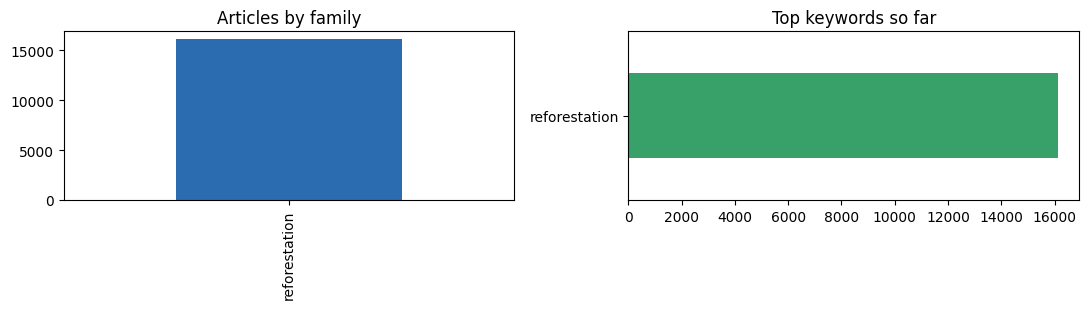

,domain,keyword,title,url,source_domain,seendate,language,country
16109,reforestation,reforestation,Gondola project at Kaukonahua Ranch sparks debate,https://www.yahoo.com/news/articles/gondola-pr...,yahoo.com,20251102T183000Z,English,United States
16110,reforestation,reforestation,"Get to Know Eliud Kipchoge Wife , Grace",https://www.yahoo.com/entertainment/celebrity/...,yahoo.com,20251102T183000Z,English,United States
16111,reforestation,reforestation,"Get to Know Eliud Kipchoge Wife , Grace",https://www.aol.com/lifestyle/know-eliud-kipch...,aol.com,20251102T164500Z,English,United States
16112,reforestation,reforestation,Gondola project at Kaukonahua Ranch sparks deb...,https://www.staradvertiser.com/2025/11/02/hawa...,staradvertiser.com,20251102T120000Z,English,United States
16113,reforestation,reforestation,Emerald Coast : Nicaragua hidden jewel,https://www.cnn.com/travel/article/nicaragua-e...,cnn.com,20251101T043000Z,English,United States


Progress: 2/11 keywords | 19009 articles so far | elapsed 4.9 hr | ETA 22.0 hr


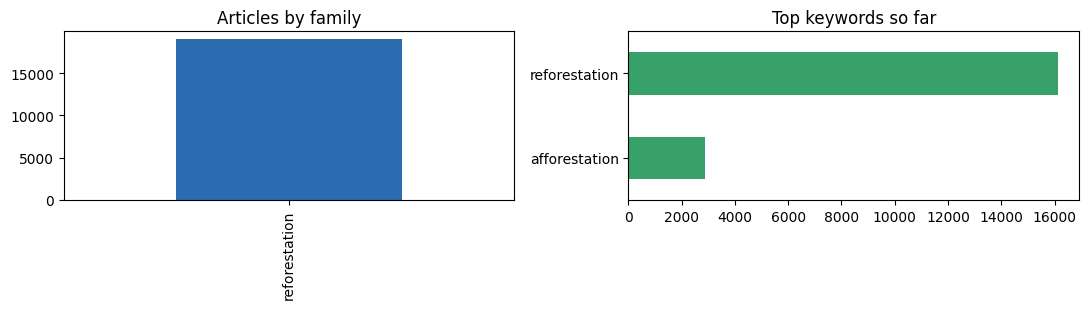

,domain,keyword,title,url,source_domain,seendate,language,country
19004,reforestation,afforestation,Bahrain News : Tree - planting project is back...,https://www.gdnonline.com:443/Details/1370442,gdnonline.com,20251207T223000Z,English,United States
19005,reforestation,afforestation,China has planted so many trees it changed the...,https://www.livescience.com/planet-earth/plant...,livescience.com,20251203T190000Z,English,United States
19006,reforestation,afforestation,A place - based assessment of biodiversity int...,https://www.nature.com/articles/s41586-025-097...,nature.com,20251203T181500Z,English,United States
19007,reforestation,afforestation,Riyadh Plan Gains Sustainability Edge,https://thearabianpost.com/riyadh-plan-gains-s...,thearabianpost.com,20251203T131500Z,English,United States
19008,reforestation,afforestation,"Old Mining Sites are Effective Carbon Sinks , ...",https://www.azocleantech.com/news.aspx?NewsID=...,azocleantech.com,20251203T123000Z,English,United States


Progress: 3/11 keywords | 33072 articles so far | elapsed 7.6 hr | ETA 20.2 hr


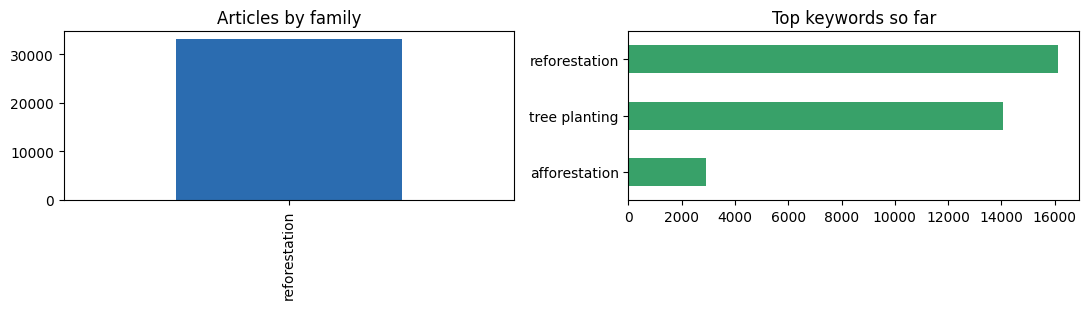

,domain,keyword,title,url,source_domain,seendate,language,country
33067,reforestation,tree planting,Students create impressive legacy with project...,https://www.yahoo.com/news/articles/students-c...,yahoo.com,20251101T183000Z,English,United States
33068,reforestation,tree planting,Time running out to visit the famed Gottleib N...,https://www.latimes.com/lifestyle/newsletter/2...,latimes.com,20251101T170000Z,English,United States
33069,reforestation,tree planting,Online survey seeks public input on urban fore...,https://www.mauinews.com/news/local-news/2025/...,mauinews.com,20251101T141500Z,English,United States
33070,reforestation,tree planting,"Celebrating Erie Canal history , and uncoverin...",https://auburnpub.com/life-entertainment/artic...,auburnpub.com,20251101T104500Z,English,United States
33071,reforestation,tree planting,"DNR , DTE Energy Foundation , and ReLeaf Michi...",https://www.thealpenanews.com/news/2025/11/dnr...,thealpenanews.com,20251101T083000Z,English,United States


Progress: 4/11 keywords | 34709 articles so far | elapsed 10.1 hr | ETA 17.7 hr


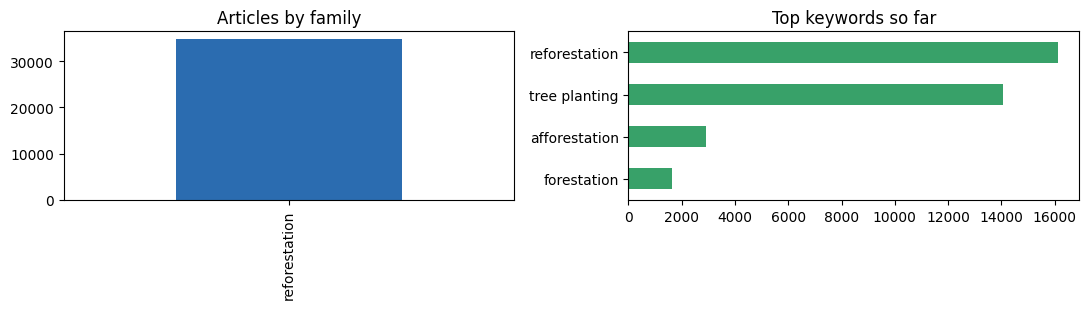

,domain,keyword,title,url,source_domain,seendate,language,country
34704,reforestation,forestation,"Israel Continues to Attack Southern Lebanon , ...",https://news.antiwar.com/2025/10/19/israel-con...,news.antiwar.com,20251019T183000Z,English,United States
34705,reforestation,forestation,Just 90 Minutes for Lasting Impact : Join Life...,https://www.pressreleasepoint.com/just-90-minu...,pressreleasepoint.com,20251011T001500Z,English,United States
34706,reforestation,forestation,Deforestation can cause eight - fold increase ...,https://phys.org/news/2025-10-deforestation-ev...,phys.org,20251008T153000Z,English,United States
34707,reforestation,forestation,Feeling patriotic ? TWO Must Re - reads for th...,https://www.greanvillepost.com/2025/11/12/feel...,greanvillepost.com,20251113T031500Z,English,United States
34708,reforestation,forestation,Meet The Startup CEO Turning Carbon Cleanup In...,https://www.benzinga.com/news/topics/25/11/488...,benzinga.com,20251112T203000Z,English,United States


Progress: 5/11 keywords | 34709 articles so far | elapsed 13.7 hr | ETA 16.4 hr


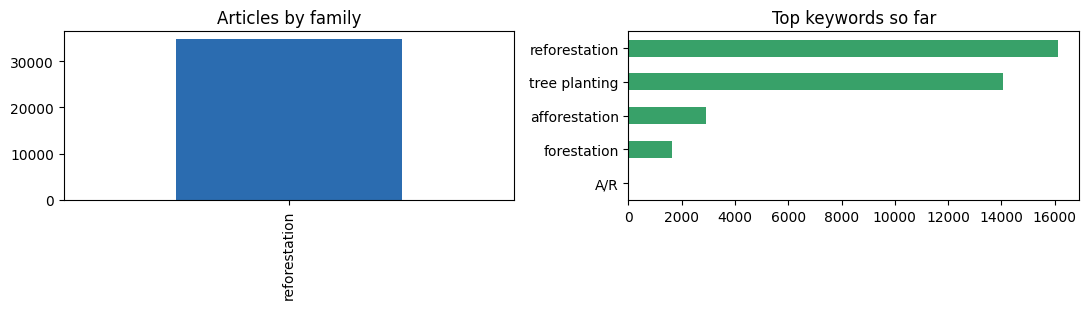

,domain,keyword,title,url,source_domain,seendate,language,country
34704,reforestation,forestation,"Israel Continues to Attack Southern Lebanon , ...",https://news.antiwar.com/2025/10/19/israel-con...,news.antiwar.com,20251019T183000Z,English,United States
34705,reforestation,forestation,Just 90 Minutes for Lasting Impact : Join Life...,https://www.pressreleasepoint.com/just-90-minu...,pressreleasepoint.com,20251011T001500Z,English,United States
34706,reforestation,forestation,Deforestation can cause eight - fold increase ...,https://phys.org/news/2025-10-deforestation-ev...,phys.org,20251008T153000Z,English,United States
34707,reforestation,forestation,Feeling patriotic ? TWO Must Re - reads for th...,https://www.greanvillepost.com/2025/11/12/feel...,greanvillepost.com,20251113T031500Z,English,United States
34708,reforestation,forestation,Meet The Startup CEO Turning Carbon Cleanup In...,https://www.benzinga.com/news/topics/25/11/488...,benzinga.com,20251112T203000Z,English,United States


Progress: 6/11 keywords | 42561 articles so far | elapsed 16.2 hr | ETA 13.5 hr


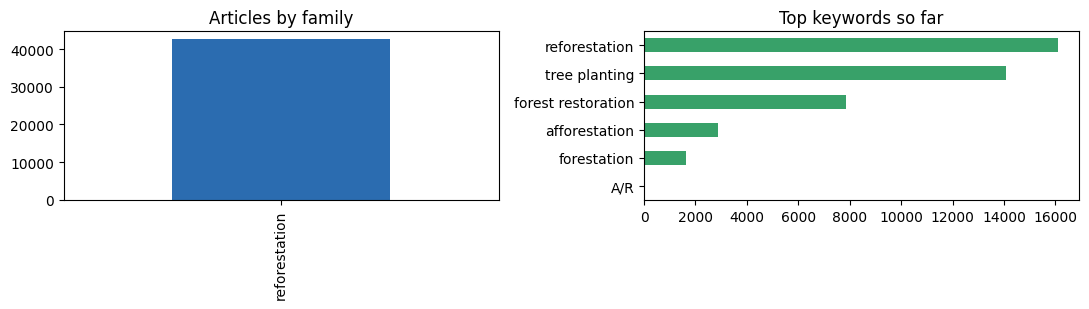

,domain,keyword,title,url,source_domain,seendate,language,country
42556,reforestation,forest restoration,FILM FEST KNOX 2025 : 96 Hours in Knoxville - ...,https://filmmakermagazine.com/132553-reviews-f...,filmmakermagazine.com,20251204T220000Z,English,United States
42557,reforestation,forest restoration,Tribe Reacquires Nearly 900 Acres of Land Near...,https://www.outsideonline.com/outdoor-adventur...,outsideonline.com,20251204T013000Z,English,United States
42558,reforestation,forest restoration,Redding Chico Eureka,https://krcrtv.com/north-coast-news/eureka-loc...,krcrtv.com,20251203T034500Z,English,United States
42559,reforestation,forest restoration,Texas Resilient Landscapes Initiative Offers $...,https://easttexasradio.com/texas-resilient-lan...,easttexasradio.com,20251202T193000Z,English,United States
42560,reforestation,forest restoration,Non - timber products have the potential to fi...,https://phys.org/news/2025-12-timber-products-...,phys.org,20251202T001500Z,English,United States


Progress: 7/11 keywords | 43194 articles so far | elapsed 18.9 hr | ETA 10.8 hr


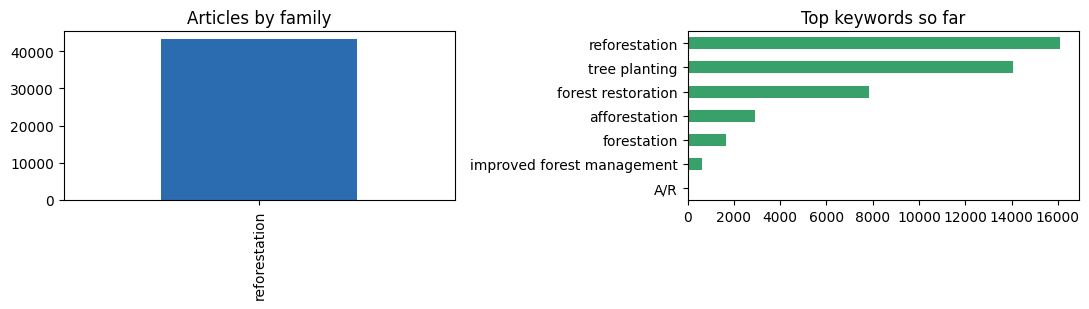

,domain,keyword,title,url,source_domain,seendate,language,country
43189,reforestation,improved forest management,"New Climate Plans to Boost Growth , Tackle Pov...",https://www.miragenews.com/new-climate-plans-t...,miragenews.com,20250221T161500Z,English,United States
43190,reforestation,improved forest management,"Space Lasers , AI Help Measure Forest Biomass",https://www.miragenews.com/space-lasers-ai-hel...,miragenews.com,20250613T203000Z,English,United States
43191,reforestation,improved forest management,Should Canada sprint to replant trees after in...,https://www.theweathernetwork.com/en/news/clim...,theweathernetwork.com,20250924T220000Z,English,United States
43192,reforestation,improved forest management,Hearings offer outlet for unease with Forest S...,https://www.eenews.net/articles/hearings-offer...,eenews.net,20250908T144500Z,English,United States
43193,reforestation,improved forest management,How a new Georgia project is helping rebuild f...,https://www.gpb.org/news/2025/11/04/how-new-ge...,gpb.org,20251105T003000Z,English,United States


Progress: 8/11 keywords | 43194 articles so far | elapsed 22.6 hr | ETA 8.5 hr


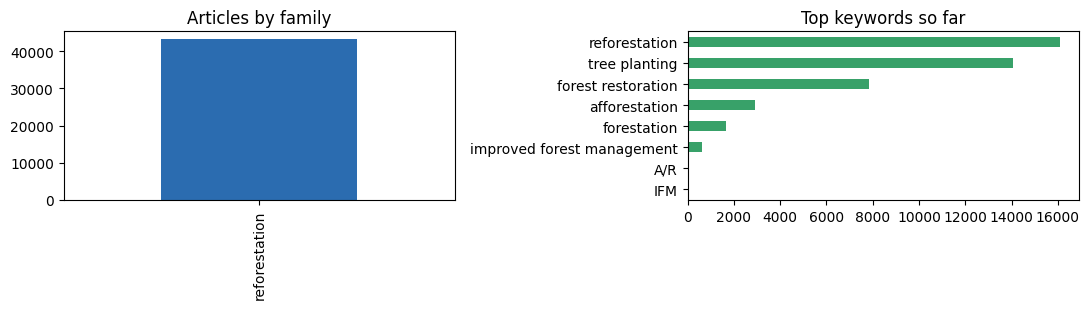

,domain,keyword,title,url,source_domain,seendate,language,country
43189,reforestation,improved forest management,"New Climate Plans to Boost Growth , Tackle Pov...",https://www.miragenews.com/new-climate-plans-t...,miragenews.com,20250221T161500Z,English,United States
43190,reforestation,improved forest management,"Space Lasers , AI Help Measure Forest Biomass",https://www.miragenews.com/space-lasers-ai-hel...,miragenews.com,20250613T203000Z,English,United States
43191,reforestation,improved forest management,Should Canada sprint to replant trees after in...,https://www.theweathernetwork.com/en/news/clim...,theweathernetwork.com,20250924T220000Z,English,United States
43192,reforestation,improved forest management,Hearings offer outlet for unease with Forest S...,https://www.eenews.net/articles/hearings-offer...,eenews.net,20250908T144500Z,English,United States
43193,reforestation,improved forest management,How a new Georgia project is helping rebuild f...,https://www.gpb.org/news/2025/11/04/how-new-ge...,gpb.org,20251105T003000Z,English,United States


Progress: 9/11 keywords | 44660 articles so far | elapsed 25.1 hr | ETA 5.6 hr


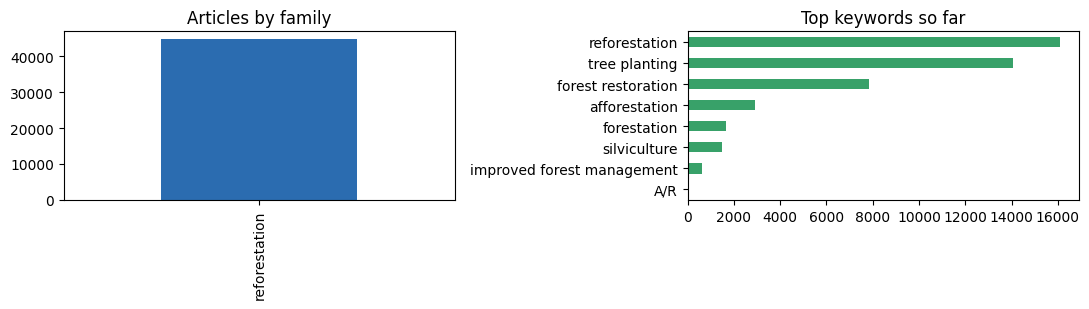

,domain,keyword,title,url,source_domain,seendate,language,country
44655,reforestation,silviculture,"Find the right trees , fall colors persist | N...",https://www.timesrepublican.com/news/outdoors-...,timesrepublican.com,20251129T074500Z,English,United States
44656,reforestation,silviculture,Pioneering Forestry Apprenticeship Welcomes Fi...,https://www.miragenews.com/pioneering-forestry...,miragenews.com,20251128T104500Z,English,United States
44657,reforestation,silviculture,Comprehensive Report Reviews the 2025 Remote S...,https://whatech.com/og/markets-research/aerosp...,whatech.com,20251125T134500Z,English,United States
44658,reforestation,silviculture,Mexico : New Reform Weakens Environmental Righ...,https://foreignpolicy.com/2025/12/08/mexican-c...,foreignpolicy.com,20251211T231500Z,English,United States
44659,reforestation,silviculture,Successful FSC Audit of SCA Forestry Operations,https://www.pulpapernews.com/20251208/17267/su...,pulpapernews.com,20251208T103000Z,English,United States


Progress: 10/11 keywords | 44685 articles so far | elapsed 27.6 hr | ETA 2.8 hr


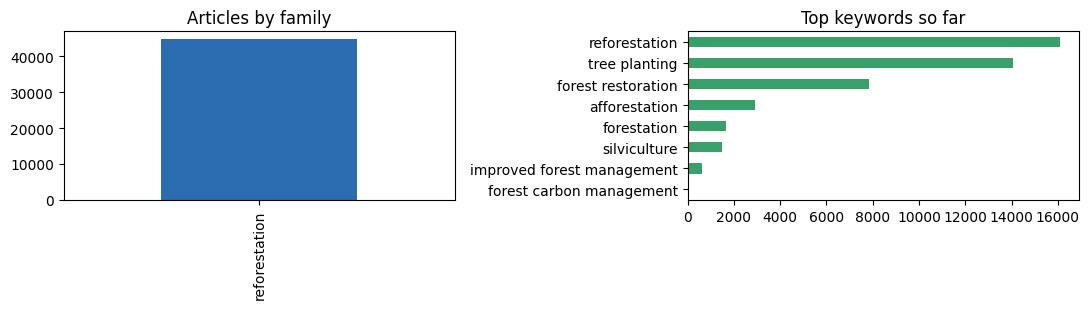

,domain,keyword,title,url,source_domain,seendate,language,country
44680,reforestation,forest carbon management,FCCP Spanish mini - course incorporated into P...,https://www.canr.msu.edu/news/fccp-spanish-min...,canr.msu.edu,20221017T191500Z,English,United States
44681,reforestation,forest carbon management,Caution urged as mining companies eye critical...,https://www.chroniclejournal.com/news/national...,chroniclejournal.com,20230208T130000Z,English,United States
44682,reforestation,forest carbon management,High uncertainty in climate impact of global f...,https://phys.org/news/2023-09-high-uncertainty...,phys.org,20230928T173000Z,English,United States
44683,reforestation,forest carbon management,Brooke Eastman helms AAAS Local Science Engage...,https://www.aaas.org/membership/member-spotlig...,aaas.org,20231129T221500Z,English,United States
44684,reforestation,forest carbon management,Frequent large - scale wildfires are turning f...,https://phys.org/news/2025-05-frequent-large-s...,phys.org,20250522T181500Z,English,United States


Progress: 11/11 keywords | 44763 articles so far | elapsed 30.4 hr | ETA 0s


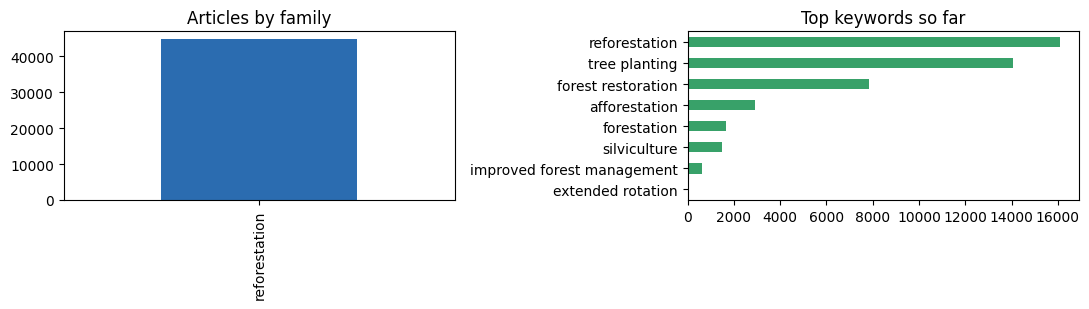

,domain,keyword,title,url,source_domain,seendate,language,country
44758,reforestation,extended rotation,What Next For P . J . Tucker After Raptors Wai...,https://www.forbes.com/sites/bobbykrivitsk/202...,forbes.com,20250301T004500Z,English,United States
44759,reforestation,extended rotation,Knick brutal playoff exit could be the wake - ...,https://dailyknicks.com/knicks-brutal-playoff-...,dailyknicks.com,20250601T163000Z,English,United States
44760,reforestation,extended rotation,A Few Intriguing Potential Lineups for the Roc...,https://www.houstonpress.com/news/a-few-intrig...,houstonpress.com,20250715T140000Z,English,United States
44761,reforestation,extended rotation,Potatoes under siege : The growing threat of p...,https://www.potatonewstoday.com/2025/07/10/pot...,potatonewstoday.com,20250710T224500Z,English,United States
44762,reforestation,extended rotation,Max Shulga Unique Journey To The Celtics Has P...,https://www.forbes.com/sites/bobbykrivitsk/202...,forbes.com,20250804T183000Z,English,United States


RETRIEVAL COMPLETE
  total articles     : 44763
  total time         : 30.4 hr
  articles / minute  : 25
  by family          : {'reforestation': np.int64(44763)}
  top keywords       : [('reforestation', 16114), ('tree planting', 14063), ('forest restoration', 7852)]


,domain,keyword,title,url,source_domain,seendate,language,country
0,reforestation,reforestation,Fathom offers Cultures of the Caribbean cruise,http://www.rustourismnews.com/2017/04/01/fatho...,rustourismnews.com,20170401T180000Z,English,United States
1,reforestation,reforestation,Celebrate Missouri trees during Arbor Days in ...,http://www.lakenewsonline.com/news/20170401/ce...,lakenewsonline.com,20170401T140000Z,English,United States
2,reforestation,reforestation,BASF receives Missouri Arbor Award,http://www.hannibal.net/news/20170401/basf-rec...,hannibal.net,20170401T140000Z,English,United States
3,reforestation,reforestation,West Seattle Blog …,http://westseattleblog.com/event/fairmount-rav...,westseattleblog.com,20170401T060000Z,English,United States
4,reforestation,reforestation,Mount Madonna seventh,http://www.santacruzsentinel.com/environment-a...,santacruzsentinel.com,20170401T040000Z,English,United States


In [11]:
import os
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def format_seconds(sec):
    """Turn a number of seconds into a short human-readable string."""
    if sec < 60:
        return f"{sec:.0f}s"
    if sec < 3600:
        return f"{sec/60:.1f} min"
    return f"{sec/3600:.1f} hr"


def _live_dashboard(df, i, n_keywords, per_keyword_counts, elapsed, eta):
    """Refresh a live view in place: progress line, a chart, and a table.
    Only meaningful when run interactively in Jupyter."""
    clear_output(wait=True)                 # erase the previous frame
    print(f"Progress: {i}/{n_keywords} keywords | "
          f"{len(df)} articles so far | elapsed {elapsed} | ETA {eta}")
    if len(df):
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
        df["domain"].value_counts().plot(
            kind="bar", ax=ax[0], color="#2b6cb0")
        ax[0].set_title("Articles by family"); ax[0].set_xlabel("")
        top = (pd.Series(per_keyword_counts).sort_values(ascending=False)
               .head(8).iloc[::-1])
        top.plot(kind="barh", ax=ax[1], color="#38a169")
        ax[1].set_title("Top keywords so far")
        plt.tight_layout(); plt.show()
        display(df.tail(5))                 # newest rows as a live table


def retrieve_all(keyword_pairs, start_date, end_date,
                 delay=REQUEST_DELAY, save_per_keyword=True, live=None):
    """Retrieve filtered articles for every keyword across the full date range.

    Loops over every keyword, then over every monthly window. Prints progress,
    running counts, and timing so you can see exactly what is happening.
    If save_per_keyword is True, writes one raw CSV per keyword as it finishes
    (into raw_by_keyword/) so an interrupted run can resume.
    Returns one combined DataFrame.
    """
    if live is None:
        live = LIVE_DISPLAY
    windows = list(month_windows(start_date, end_date))
    n_keywords = len(keyword_pairs)
    if save_per_keyword:
        os.makedirs("raw_by_keyword", exist_ok=True)

    print("=" * 60)
    print(f"STARTING RETRIEVAL")
    print(f"  keywords to search : {n_keywords}")
    print(f"  months per keyword : {len(windows)}")
    print(f"  total API calls    : {n_keywords * len(windows)}")
    print(f"  filters            : "
          f"{'English ' if FILTER_ENGLISH else ''}"
          f"{'US-source' if FILTER_US_SOURCE else ''}".strip() or "none")
    print("=" * 60)

    run_start = time.time()
    all_rows = []
    per_keyword_counts = {}

    for i, (family, keyword) in enumerate(keyword_pairs, 1):
        kw_start = time.time()
        query = build_query(keyword)
        kw_rows = []

        for w_start, w_end in windows:
            articles = fetch_window(query, w_start, w_end)
            for a in articles:
                kw_rows.append({
                    "domain": family,
                    "keyword": keyword,
                    "title": a.get("title", "").strip(),
                    "url": a.get("url", ""),
                    "source_domain": a.get("domain", ""),
                    "seendate": a.get("seendate", ""),
                    "language": a.get("language", ""),
                    "country": a.get("sourcecountry", ""),
                })
            time.sleep(delay)

        if save_per_keyword and kw_rows:
            safe = keyword.replace(" ", "_")
            pd.DataFrame(kw_rows).to_csv(
                f"raw_by_keyword/{family}_{safe}.csv", index=False)

        all_rows.extend(kw_rows)
        per_keyword_counts[keyword] = len(kw_rows)

        # --- progress line with count, timing, running total, and ETA ---
        kw_elapsed = time.time() - kw_start
        total_elapsed = time.time() - run_start
        avg_per_kw = total_elapsed / i
        eta = avg_per_kw * (n_keywords - i)
        if live:
            _live_dashboard(pd.DataFrame(all_rows), i, n_keywords,
                            per_keyword_counts,
                            format_seconds(total_elapsed), format_seconds(eta))
        else:
            print(f"[{i:>2}/{n_keywords}] {family:<4} {keyword:<32} "
                  f"{len(kw_rows):>4} articles | "
                  f"{format_seconds(kw_elapsed):>6} | "
                  f"running total {len(all_rows):>5} | "
                  f"ETA {format_seconds(eta)}")

    total_time = time.time() - run_start
    df = pd.DataFrame(all_rows)

    # --- final summary block ---
    print("=" * 60)
    print("RETRIEVAL COMPLETE")
    print(f"  total articles     : {len(df)}")
    print(f"  total time         : {format_seconds(total_time)}")
    if len(df):
        print(f"  articles / minute  : {len(df)/(total_time/60):.0f}")
    print(f"  by family          : "
          f"{dict(df['domain'].value_counts()) if len(df) else {}}")
    top = sorted(per_keyword_counts.items(), key=lambda x: -x[1])[:3]
    print(f"  top keywords       : {top}")
    print("=" * 60)
    return df


# Run it. (This contacts GDELT and may take several minutes.)
raw_df = retrieve_all(KEYWORD_PAIRS, START_DATE, END_DATE)
raw_df.head()

### Save the raw results

Before any cleaning, we save the complete raw pull to its own CSV. Keeping an untouched raw copy is good practice: if you later change how you clean or deduplicate, you can always go back to exactly what GDELT returned without re-running the pull.

In [12]:
def save_raw(df, label="gdelt_climate_news_RAW"):
    """Save the untouched raw results to a timestamped CSV."""
    span = f"{START_DATE:%Y%m%d}_{END_DATE:%Y%m%d}"
    filters = []
    if FILTER_ENGLISH:   filters.append("eng")
    if FILTER_US_SOURCE: filters.append("us")
    tag = "_".join(filters) if filters else "all"
    path = f"{label}_{tag}_{span}.csv"
    df.to_csv(path, index=False, encoding="utf-8")
    print(f"Saved RAW: {len(df)} rows to {path}")
    return path


save_raw(raw_df)

Saved RAW: 44763 rows to gdelt_climate_news_RAW_eng_us_20150101_20251230.csv


'gdelt_climate_news_RAW_eng_us_20150101_20251230.csv'

## 8. Reconciliation and Quality Checks

Before cleaning, this section checks that the pull behaved as expected. It answers three questions:

1. **How does this run compare to a previous one?** Paste old per-keyword counts into `OLD_COUNTS` to see a side-by-side with the difference.
2. **Did any keyword hit the 250 record ceiling in a single month?** Because we fetch one month at a time, the 250 cap now applies *per month*. If any keyword-month returns exactly 250, that month was likely truncated and you are missing articles - the fix is to fetch that keyword in shorter windows (for example weekly).
3. **Did the filters actually take?** It lists the languages and source countries present. With `sourcelang:eng` and `sourcecountry:US` on, you should see only English and only United States. Anything else means a filter did not apply.

Run this after retrieval and read the flags. It changes no data - it only reports.

In [13]:
# --- Optional: paste per-keyword counts from a previous run to compare ---
# (These are the numbers from the earlier proof-of-concept run. Edit freely.)
OLD_COUNTS = {
    "ocean alkalinity enhancement": 107
}

CAP = 250   # the DOC API per-request record ceiling

def reconcile(raw_df, old_counts=None, cap=CAP):
    print("=" * 60)
    print("RECONCILIATION AND QUALITY CHECKS")
    print("=" * 60)

    if raw_df.empty:
        print("  raw_df is empty - nothing to check.")
        return

    # 1. Per-keyword totals for this run
    new_counts = raw_df.groupby("keyword").size().to_dict()

    # 2. Per-(keyword, month) counts, to detect single-month truncation
    tmp = raw_df.copy()
    tmp["month"] = pd.to_datetime(
        tmp["seendate"], format="%Y%m%dT%H%M%SZ", errors="coerce"
    ).dt.to_period("M")
    window_counts = tmp.groupby(["keyword", "month"]).size()
    truncated = window_counts[window_counts >= cap]

    # 3. Per-keyword table, with old comparison if provided
    header = f"  {'keyword':<34}{'new':>6}"
    if old_counts:
        header += f"{'old':>6}{'delta':>8}"
    print(header)
    print("  " + "-" * (len(header) - 2))
    for kw in sorted(new_counts, key=lambda k: -new_counts[k]):
        line = f"  {kw:<34}{new_counts[kw]:>6}"
        if old_counts and kw in old_counts:
            delta = new_counts[kw] - old_counts[kw]
            line += f"{old_counts[kw]:>6}{delta:>+8}"
        print(line)

    # 4. Truncation flag
    print("\n  --- Truncation check (any month at the {} cap) ---".format(cap))
    if len(truncated):
        print("  WARNING: these keyword-months hit the cap and may be cut off:")
        for (kw, mo), n in truncated.items():
            print(f"    {kw} / {mo}: {n}")
        print("  -> re-fetch these keywords in shorter (weekly) windows.")
    else:
        print("  OK: no single month hit the cap; monthly chunking is sufficient.")

    # 5. Filter adherence
    print("\n  --- Filter adherence ---")
    langs = raw_df["language"].value_counts().to_dict()
    print(f"  languages present : {langs}")
    non_en = {k: v for k, v in langs.items()
              if k and k.lower() not in ("english", "eng")}
    print("  " + ("OK: English-only held." if not non_en
                  else f"WARNING: non-English present -> {non_en}"))

    countries = raw_df["country"].value_counts().to_dict()
    print(f"  countries present : {countries}")
    non_us = {k: v for k, v in countries.items()
              if k and k.upper() not in ("US", "UNITED STATES")}
    print("  " + ("OK: US-source-only held." if not non_us
                  else f"NOTE: non-US present -> {non_us}"))
    print("=" * 60)


reconcile(raw_df, OLD_COUNTS)

RECONCILIATION AND QUALITY CHECKS
  keyword                              new   old   delta
  ------------------------------------------------------
  reforestation                      16114
  tree planting                      14063
  forest restoration                  7852
  afforestation                       2895
  forestation                         1637
  silviculture                        1466
  improved forest management           633
  extended rotation                     78
  forest carbon management              25

  --- Truncation check (any month at the 250 cap) ---
    afforestation / 2021-04: 250
    forest restoration / 2019-08: 255
    forest restoration / 2020-01: 252
    forest restoration / 2020-02: 250
    improved forest management / 2018-11: 250
    reforestation / 2017-06: 268
    reforestation / 2017-09: 260
    reforestation / 2018-05: 257
    reforestation / 2018-10: 259
    reforestation / 2018-11: 255
    reforestation / 2019-10: 346
    reforestation /

## 9. Cleaning and Deduplication

News wire stories are often reprinted by many outlets, so the same headline can appear many times. We keep the **earliest** copy of each and record how many duplicates existed, so corpus size is reported honestly (raw counts overstate coverage).

Steps:
1. Drop rows with an empty link or headline.
2. Convert `seendate` to a proper date so we can sort by time.
3. Collapse duplicate headlines, keeping the earliest, and add a `dup_count` column.

In [15]:
def clean_and_dedupe(df):
    """Clean the raw results and remove duplicate headlines (keep earliest)."""
    df = df.copy()

    # 1. Drop rows missing a link or a headline
    df = df[(df["url"].str.strip() != "") & (df["title"].str.strip() != "")]

    # 2. Parse the GDELT date (format: 20260115T143000Z) into a real datetime
    df["date_parsed"] = pd.to_datetime(
        df["seendate"], format="%Y%m%dT%H%M%SZ", errors="coerce")
    df = df.sort_values("date_parsed", na_position="last")

    # 3. Normalize the headline for duplicate detection
    df["title_key"] = (df["title"].str.lower()
                       .str.replace(r"[^a-z0-9 ]", " ", regex=True)
                       .str.replace(r"\s+", " ", regex=True)
                       .str.strip())

    # count copies, then keep the earliest of each
    df["dup_count"] = df.groupby("title_key")["url"].transform("size")
    df = df.drop_duplicates("title_key", keep="first")

    df = df.drop(columns=["title_key"]).reset_index(drop=True)
    return df


clean_start = time.time()
clean_df = clean_and_dedupe(raw_df)

print("=" * 60)
print("CLEANING SUMMARY")
print(f"  raw rows in         : {len(raw_df)}")
print(f"  clean rows out      : {len(clean_df)}")
print(f"  removed (dupe/empty): {len(raw_df) - len(clean_df)}"
      f"  ({100*(len(raw_df)-len(clean_df))/max(len(raw_df),1):.1f}%)")
if len(clean_df):
    print(f"  unique titles       : {clean_df['title'].nunique()}")
    print(f"  by family           : {dict(clean_df['domain'].value_counts())}")
    print(f"  with country filled : {int((clean_df['country'].str.strip() != '').sum())}"
          f" of {len(clean_df)}")
    most_dupes = clean_df.nlargest(3, 'dup_count')[['keyword', 'dup_count', 'title']]
    print(f"  most-syndicated headlines (copies seen):")
    for _, r in most_dupes.iterrows():
        print(f"    {r['dup_count']:>3}x  {r['title'][:50]}")
print(f"  cleaning time       : {format_seconds(time.time() - clean_start)}")
print("=" * 60)
clean_df[["domain", "keyword", "title", "country", "date_parsed"]].head()

CLEANING SUMMARY
  raw rows in         : 44763
  clean rows out      : 28763
  removed (dupe/empty): 16000  (35.7%)
  unique titles       : 28763
  by family           : {'reforestation': np.int64(28763)}
  with country filled : 28763 of 28763
  most-syndicated headlines (copies seen):
    254x  Events - GwdToday
    188x  Q & A : California looks to keep landmark climate 
    147x  Featured Events
  cleaning time       : 0s


,domain,keyword,title,country,date_parsed
0,reforestation,silviculture,Cuba 2016 : Economic Austerity Without Shock T...,United States,2017-01-01 15:30:00
1,reforestation,silviculture,Untitled,United States,2017-01-02 15:00:00
2,reforestation,silviculture,STEVEN MARK CLARK,United States,2017-01-03 21:00:00
3,reforestation,silviculture,Ranger Districts senior employee Lupe Wilso...,United States,2017-01-04 01:15:00
4,reforestation,silviculture,Forestry Aid ( General ),United States,2017-01-04 08:30:00


### Save the cleaned results

Now save the cleaned, deduplicated table as its own CSV, separate from the raw file. You now have two files: the raw pull (everything GDELT returned) and the cleaned corpus (one row per unique article). Downstream sentiment scoring uses the cleaned file.

In [16]:
def save_clean(df, label="gdelt_climate_news_CLEAN"):
    """Save the cleaned, deduplicated results to a timestamped CSV."""
    span = f"{START_DATE:%Y%m%d}_{END_DATE:%Y%m%d}"
    filters = []
    if FILTER_ENGLISH:   filters.append("eng")
    if FILTER_US_SOURCE: filters.append("us")
    tag = "_".join(filters) if filters else "all"
    path = f"{label}_{tag}_{span}.csv"
    df.to_csv(path, index=False, encoding="utf-8")
    print(f"Saved CLEAN: {len(df)} rows to {path}")
    return path


save_clean(clean_df)

Saved CLEAN: 28763 rows to gdelt_climate_news_CLEAN_eng_us_20150101_20251230.csv


'gdelt_climate_news_CLEAN_eng_us_20150101_20251230.csv'

## 10. Scraping the Article Body Text

GDELT gives you the headline and the link, but **not the article body**. If you want full-text sentiment (not just headline sentiment), you fetch each article's text from its URL. This section does that.

**What web scraping is:** downloading a web page and extracting the readable article text from it, stripping away menus, ads, and navigation. We use two libraries:

- **trafilatura** (primary) - a well-regarded article-text extractor (Barbaresi, 2021).
- **newspaper3k** (fallback) - tried if trafilatura returns nothing.

**Being a good citizen.** The function honors each site's `robots.txt` (the file where a site states what automated tools may access), pauses between requests, and records a status for every article so you know what succeeded. Some articles will fail: paywalls, dead links, and login walls are normal, especially for older URLs. Those rows keep an empty body and a status code explaining why.

Install the libraries once with: `pip install trafilatura newspaper3k`

In [ ]:
# pip install trafilatura newspaper3k     # <- run once if not installed

from urllib.parse import urlsplit
from urllib.robotparser import RobotFileParser

_robots_cache = {}

def _allowed(url):
    """Check the site's robots.txt to see if fetching this URL is permitted."""
    host = urlsplit(url).netloc
    if host not in _robots_cache:
        rp = RobotFileParser(f"https://{host}/robots.txt")
        try:
            rp.read()
        except Exception:
            rp = None                      # no robots.txt reachable; allow
        _robots_cache[host] = rp
    rp = _robots_cache[host]
    return True if rp is None else rp.can_fetch("*", url)


def fetch_body(url):
    """Return (body_text, status) for one article URL.

    status is one of: ok, ok_fallback, robots_disallowed, fetch_failed.
    """
    import trafilatura
    if not _allowed(url):
        return "", "robots_disallowed"
    try:
        html = trafilatura.fetch_url(url)
        if html:
            text = trafilatura.extract(html, favor_precision=True)
            if text:
                return text, "ok"
        # fallback to newspaper3k
        from newspaper import Article
        art = Article(url)
        art.download(); art.parse()
        if art.text:
            return art.text, "ok_fallback"
    except Exception:
        pass
    return "", "fetch_failed"

### Run the body scrape

The cell below adds two columns to the cleaned table: `body` (the article text) and `fetch_status` (what happened). 

**Start small.** Scraping is slow (about 1-2 seconds per article) and hits real websites, so the `LIMIT` below runs only the first 25 articles as a test. Set `LIMIT = None` to scrape the whole corpus once you are happy it works. Expect this to take roughly one second per article plus the polite delay.

In [ ]:
from collections import Counter

BODY_DELAY = 1.0        # seconds between article fetches
LIMIT = 25              # scrape only the first 25 as a test; set None for all

def add_bodies(df, limit=LIMIT, delay=BODY_DELAY):
    """Fetch body text for each article; add body and fetch_status columns.
    Prints running progress, success/fail counts, timing, and an ETA."""
    df = df.copy()
    subset = df.head(limit) if limit else df
    n = len(subset)

    print("=" * 60)
    print(f"SCRAPING BODY TEXT for {n} articles"
          f"{' (LIMIT set; increase to scrape all)' if limit else ''}")
    print("=" * 60)

    run_start = time.time()
    bodies, statuses = [], []
    status_counts = Counter()

    for i, url in enumerate(subset["url"], 1):
        text, status = fetch_body(url)
        bodies.append(text)
        statuses.append(status)
        status_counts[status] += 1

        # progress every 5 articles: counts, timing, ETA
        if i % 5 == 0 or i == n:
            elapsed = time.time() - run_start
            rate = elapsed / i
            eta = rate * (n - i)
            ok = status_counts["ok"] + status_counts["ok_fallback"]
            print(f"  [{i:>4}/{n}] ok {ok:>4} | "
                  f"failed {status_counts['fetch_failed']:>4} | "
                  f"blocked {status_counts['robots_disallowed']:>3} | "
                  f"elapsed {format_seconds(elapsed)} | ETA {format_seconds(eta)}")
        time.sleep(delay)

    subset = subset.copy()
    subset["body"] = bodies
    subset["fetch_status"] = statuses

    total_time = time.time() - run_start
    ok = status_counts["ok"] + status_counts["ok_fallback"]
    print("=" * 60)
    print("SCRAPING COMPLETE")
    print(f"  attempted          : {n}")
    print(f"  succeeded          : {ok}  ({100*ok/max(n,1):.0f}%)")
    print(f"  failed             : {status_counts['fetch_failed']}")
    print(f"  blocked by robots  : {status_counts['robots_disallowed']}")
    print(f"  total time         : {format_seconds(total_time)}")
    print(f"  seconds / article  : {total_time/max(n,1):.1f}")
    if ok:
        lengths = [len(b) for b in bodies if b]
        print(f"  median body length : {int(sorted(lengths)[len(lengths)//2])} chars")
    print("=" * 60)
    return subset


bodies_df = add_bodies(clean_df)
bodies_df[["keyword", "title", "fetch_status"]].head()

### Save the corpus with body text

Save the version that includes the scraped bodies as a third CSV. You now have three files: RAW (everything GDELT returned), CLEAN (deduplicated metadata), and WITH_BODY (cleaned plus article text). Body text can be large, so this file will be bigger than the others.

In [ ]:
def save_with_body(df, label="gdelt_climate_news_WITH_BODY"):
    """Save the cleaned corpus with scraped body text."""
    span = f"{START_DATE:%Y%m%d}_{END_DATE:%Y%m%d}"
    filters = []
    if FILTER_ENGLISH:   filters.append("eng")
    if FILTER_US_SOURCE: filters.append("us")
    tag = "_".join(filters) if filters else "all"
    path = f"{label}_{tag}_{span}.csv"
    df.to_csv(path, index=False, encoding="utf-8")
    print(f"Saved WITH_BODY: {len(df)} rows to {path}")
    return path


save_with_body(bodies_df)

## 11. Optional: Sentiment and Volume Over Time (Triangulation)

Besides article lists, the DOC API can return GDELT's own summaries of a topic, which are useful as an independent cross-check against sentiment you compute yourself later:

- **`mode=TimelineVol`** - how much coverage a term received over time (its share of global news).
- **`mode=TimelineTone`** - the average tone of that coverage over time.

These are optional. They give a GDELT-computed sentiment-and-attention signal you can compare against your own scores, strengthening a methods chapter. The function below fetches one such timeline for one keyword.

In [ ]:
def fetch_timeline(keyword, mode="TimelineTone",
                   start=START_DATE, end=END_DATE):
    """Fetch a GDELT timeline (TimelineTone or TimelineVol) for one keyword."""
    params = {
        "query": build_query(keyword),
        "mode": mode,
        "format": "json",
        "startdatetime": start.strftime("%Y%m%d%H%M%S"),
        "enddatetime": end.strftime("%Y%m%d%H%M%S"),
    }
    url = DOC_API + "?" + urlencode(params)
    try:
        reply = requests.get(url, headers=USER_AGENT, timeout=60)
        if reply.status_code == 200 and reply.text.strip().startswith("{"):
            return reply.json()
    except requests.RequestException:
        pass
    return {}


# Example (uncomment to run):
# tone_timeline = fetch_timeline("direct air capture", mode="TimelineTone")
# print(json.dumps(tone_timeline, indent=1)[:500])

## 12. Limitations

An honest record of what this pipeline does and does not capture:

- **Source country filtering is strict.** `sourcecountry:US` excludes US outlets whose country GDELT could not resolve, so it undercounts. Restricting to US sources also changes the population from global anglophone coverage to US-outlet coverage - a scoping decision to state in the methods and, for a confirmatory study, to preregister.
- **Relevance ranking and the 250 cap.** Even with monthly chunking, an extremely high-volume month could exceed 250 articles and be truncated; narrow the window further if a keyword saturates.
- **Recent coverage bias.** The DOC API is most reliable from about 2017 onward. Older corpora need GDELT's bulk files.
- **Headlines, not full text.** This pipeline collects headlines and metadata. Article bodies must be fetched separately from each URL if full-text sentiment is required.
- **Document-level tone.** GDELT's own tone (if used via the timelines) is computed for the whole document and cannot isolate sentiment toward a specific technology.

## 13. References and Resources

**Cited works** (DOIs verified against Crossref, July 2026):

- Barbaresi, A. (2021). Trafilatura: A web scraping library and command-line tool for text discovery and extraction. Proceedings of the 59th Annual Meeting of the Association for Computational Linguistics: System Demonstrations, 122-131. https://doi.org/10.18653/v1/2021.acl-demo.15
- Leetaru, K., and Schrodt, P. A. (2013). GDELT: Global data on events, location, and tone, 1979-2012. International Studies Association Annual Convention. (No DOI; conference paper.)
- McKinney, W. (2010). Data structures for statistical computing in Python. Proceedings of the 9th Python in Science Conference, 56-61. https://doi.org/10.25080/Majora-92bf1922-00a
- Hutto, C. J., and Gilbert, E. (2014). VADER: A parsimonious rule-based model for sentiment analysis of social media text. Proceedings of the International AAAI Conference on Web and Social Media, 8(1), 216-225. https://doi.org/10.1609/icwsm.v8i1.14550 (for the downstream sentiment scoring step)

**Resources:**

- GDELT DOC 2.0 API: https://api.gdeltproject.org/api/v2/doc/doc
- GDELT DOC 2.0 API documentation: https://blog.gdeltproject.org/gdelt-doc-2-0-api-debuts/
- GDELT project home: https://www.gdeltproject.org
- pandas documentation: https://pandas.pydata.org
- requests documentation: https://requests.readthedocs.io

*GDELT data and API are GDELT Project resources; cite as technical documentation with a retrieval date. This notebook retrieves data only; sentiment scoring, human validation, and statistical analysis are documented separately in the project methodology.*

## 14. Export This Notebook as a Shareable HTML Report

This turns the notebook, with all its printed output, tables, and figures, into a single self-contained HTML file you can open in any browser or email to a collaborator.

**Important distinction:**
- **Live updating** (the dashboard in Section 7) happens only while you run the notebook in Jupyter, because live updating needs Python running behind it.
- **The HTML export** is a *snapshot*: it freezes whatever outputs exist at export time into a static file. Run the notebook fully first, then export, so the figures and tables are populated in the snapshot.

Two ways to export, below: a quick in-notebook command that saves an HTML file locally, and a note on committing it to GitHub once your repository is set up.

In [ ]:
import subprocess
import datetime as dt

# Option 1: save the HTML report locally, next to your data.
# This runs nbconvert on THIS notebook file. Set the notebook filename
# to match what you saved it as.
NOTEBOOK_FILENAME = "GDELT_climate_news_retrieval_documented.ipynb"
LOCAL_REPORT_DIR = CODE_PATH_LOCAL + "/gdelt/reports"   # change if you like

def export_html(notebook=NOTEBOOK_FILENAME, out_dir=LOCAL_REPORT_DIR):
    """Export this notebook to a self-contained HTML report saved locally."""
    import os
    os.makedirs(out_dir, exist_ok=True)
    stamp = dt.datetime.now().strftime("%Y%m%d")
    out_name = f"gdelt_retrieval_report_{stamp}"
    cmd = ["jupyter", "nbconvert", "--to", "html",
           "--output-dir", out_dir, "--output", out_name, notebook]
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode == 0:
        print(f"Saved HTML report to: {out_dir}/{out_name}.html")
    else:
        print("Export failed:\n", result.stderr[-500:])

# Uncomment to run after you have executed the whole notebook:
# export_html()

### Option 2: publish the report to GitHub

Once your GitHub repository is set up, you can share the HTML report so anyone can view it:

1. Save the notebook and export the HTML with the cell above.
2. Commit both to your repository, for example into a `reports/` folder:

   ```
   git add reports/gdelt_retrieval_report_YYYYMMDD.html
   git commit -m "Add GDELT retrieval report"
   git push
   ```

3. Update `CODE_URL_GITHUB` in the configuration (Section 3) and set `USE_GITHUB_LINK = True` so the report links back to your code.

**Tip:** to make the HTML viewable directly in a browser (not just downloadable), enable GitHub Pages on the repository, or paste the file's GitHub URL into a viewer such as htmlpreview.github.io. Raw HTML files on GitHub display as source unless Pages is enabled.